# Adaptive Memory — EDA & Evaluation Starter

This notebook is where the data cleaning, visualization, and benchmark
comparison work happens (the actual "EDA" deliverable for the review).

Sections:
1. Load a benchmark dataset (LoCoMo / LongMemEval / a custom conversation set)
2. Clean it (dedupe, normalize, handle missing fields)
3. Run it through the memory pipeline
4. Compare against truncation and single-summary baselines
5. Visualize results


In [14]:
import sys
sys.path.append("..")  # so `memory_engine` imports work from evaluation/

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from memory_engine.pipeline import process_message, get_store
from memory_engine.retrieve import retrieve_relevant
from memory_engine.categorize import _get_client
from memory_engine.config import GROQ_MODEL


## 1. Load a dataset

Download LoCoMo / LongMemEval / ConvoMem into `../data/` and point this at
the actual file. For now this loads a tiny placeholder conversation so the
rest of the notebook runs end-to-end without external data.


In [2]:
with open("../data/locomo10.json", encoding="utf-8") as f:
    raw = json.load(f)
print(type(raw))
print("Number of conversations:", len(raw))




<class 'list'>
Number of conversations: 10


In [3]:
rows = []

for conversation in raw:
    conversation_id = conversation["sample_id"]
    sessions = conversation["conversation"]

    for session_name, session_data in sessions.items():
        if not session_name.startswith("session_") or session_name.endswith("_date_time"):
            continue

        for turn in session_data:
            rows.append({
                "conversation_id": conversation_id,
                "session": session_name,
                "speaker": turn.get("speaker"),
                "dia_id": turn.get("dia_id"),
                "text": turn.get("text")
            })

df_raw = pd.DataFrame(rows)

print("Total number of turns:", len(df_raw))

conversation_lengths = df_raw.groupby("conversation_id").size()

print("\nTurns per conversation:")
print(conversation_lengths)

print("\nConversation length statistics:")
print(conversation_lengths.describe())


Total number of turns: 5882

Turns per conversation:
conversation_id
conv-26    419
conv-30    369
conv-41    663
conv-42    629
conv-43    680
conv-44    675
conv-47    689
conv-48    681
conv-49    509
conv-50    568
dtype: int64

Conversation length statistics:
count     10.00000
mean     588.20000
std      118.01676
min      369.00000
25%      523.75000
50%      646.00000
75%      678.75000
max      689.00000
dtype: float64


## 2. Clean the data

Typical issues in raw conversation logs: duplicate/near-duplicate turns,
empty strings, inconsistent whitespace, missing role labels. Adjust these
checks once you're working with the real benchmark files — their schemas
differ from this placeholder.


In [4]:
def clean_turns(df: pd.DataFrame, raw_data) -> pd.DataFrame:
    df = df.copy()

    # Add session timestamp
    session_dates = {}

    for conversation in raw_data:
        conversation_id = conversation["sample_id"]
        sessions = conversation["conversation"]

        for session_name, session_date in sessions.items():
            if session_name.startswith("session_") and session_name.endswith("_date_time"):
                session_name_only = session_name.replace("_date_time", "")
                session_dates[(conversation_id, session_name_only)] = session_date

    df["timestamp"] = df.apply(
        lambda row: session_dates.get(
            (row["conversation_id"], row["session"])
        ),
        axis=1
    )

    # Remove extra spaces
    df["text"] = df["text"].str.strip()

    # Convert empty text to missing values
    df["text"] = df["text"].replace("", np.nan)

    # Remove rows with missing text
    df = df.dropna(subset=["text"])

    # Remove duplicate dialogue turns
    df = df.drop_duplicates(
        subset=["conversation_id", "session", "dia_id"]
    )

    # Normalize spaces inside text
    df["text"] = df["text"].str.replace(r"\s+", " ", regex=True)

    # Reset index
    df = df.reset_index(drop=True)

    return df


df_clean = clean_turns(df_raw, raw)

print("Rows before cleaning:", len(df_raw))
print("Rows after cleaning:", len(df_clean))
print("Rows removed:", len(df_raw) - len(df_clean))

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned data:")
display(df_clean.head())

Rows before cleaning: 5882
Rows after cleaning: 5882
Rows removed: 0

Missing values after cleaning:
conversation_id    0
session            0
speaker            0
dia_id             0
text               0
timestamp          0
dtype: int64

Cleaned data:


,conversation_id,session,speaker,dia_id,text,timestamp
0,conv-26,session_1,Caroline,D1:1,Hey Mel! Good to see you! How have you been?,"1:56 pm on 8 May, 2023"
1,conv-26,session_1,Melanie,D1:2,Hey Caroline! Good to see you! I'm swamped wit...,"1:56 pm on 8 May, 2023"
2,conv-26,session_1,Caroline,D1:3,I went to a LGBTQ support group yesterday and ...,"1:56 pm on 8 May, 2023"
3,conv-26,session_1,Melanie,D1:4,"Wow, that's cool, Caroline! What happened that...","1:56 pm on 8 May, 2023"
4,conv-26,session_1,Caroline,D1:5,The transgender stories were so inspiring! I w...,"1:56 pm on 8 May, 2023"


## 3. Run the memory pipeline on each turn

This calls your real `memory_engine` pipeline (categorize -> score ->
contradiction check -> store) on every cleaned turn, and logs what happened
to each one.


In [8]:
print("Total turns:", len(df_clean))

print("\nTurns per conversation:")
print(df_clean.groupby("conversation_id").size())

print("\nTurns per speaker:")
print(df_clean["speaker"].value_counts())

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate dialogue IDs:")
print(df_clean.duplicated(
    subset=["conversation_id", "session", "dia_id"]
).sum())

Total turns: 5882

Turns per conversation:
conversation_id
conv-26    419
conv-30    369
conv-41    663
conv-42    629
conv-43    680
conv-44    675
conv-47    689
conv-48    681
conv-49    509
conv-50    568
dtype: int64

Turns per speaker:
speaker
John        1017
Tim          344
James        343
Deborah      341
Jolene       340
Audrey       338
Andrew       337
Maria        328
Nate         316
Joanna       313
Calvin       285
Dave         283
Evan         256
Sam          253
Caroline     211
Melanie      208
Jon          185
Gina         184
Name: count, dtype: int64

Missing values:
conversation_id    0
session            0
speaker            0
dia_id             0
text               0
timestamp          0
dtype: int64

Duplicate dialogue IDs:
0


## 4. Compare against baselines

Placeholder baseline implementations — swap in real ones (simple truncation
keeping last N turns; a single LLM-generated summary) so the comparison
means something for your report. The metric functions below are stubs to
fill in once you're running the real benchmarks.


In [13]:
def truncation_baseline(turns, keep_last=3):
    return turns[-keep_last:]


conv_id = df_clean["conversation_id"].iloc[0]

conv_turns = df_clean[
    df_clean["conversation_id"] == conv_id
]["text"].tolist()

truncated_turns = truncation_baseline(conv_turns, keep_last=3)

print("Conversation:", conv_id)
print("Total turns:", len(conv_turns))
print("Turns kept:", len(truncated_turns))

print("\nLast 3 turns:")
for turn in truncated_turns:
    print(turn)

Conversation: conv-26
Total turns: 419
Turns kept: 3

Last 3 turns:
Glad you agree, Caroline. Appreciate the support of those close to me. Their encouragement made me who I am.
Glad you had support. Being yourself is great!
Yeah, that's true! It's so freeing to just be yourself and live honestly. We can really accept who we are and be content.


In [16]:
def summarize_chunk(text):
    client = _get_client()

    prompt = f"""
Summarize this part of a conversation.
Keep important facts, preferences, goals, decisions, and personal information.
Do not add information that is not present.

Conversation:
{text}
"""

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        max_tokens=700,
    )

    return response.choices[0].message.content.strip()


def single_summary_baseline(turns, chunk_size=100):
    chunks = [
        turns[i:i + chunk_size]
        for i in range(0, len(turns), chunk_size)
    ]

    chunk_summaries = []

    for i, chunk in enumerate(chunks):
        chunk_text = "\n".join(chunk)

        summary = summarize_chunk(chunk_text)
        chunk_summaries.append(summary)

        print(f"Chunk {i + 1}/{len(chunks)} summarized.")

        time.sleep(10)

    combined_text = "\n".join(chunk_summaries)

    client = _get_client()

    prompt = f"""
Create one final summary of the following conversation summaries.

Keep the important facts, preferences, goals, decisions, and personal
information from across the entire conversation.

Do not add information that is not present.

Conversation summaries:
{combined_text}
"""

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        max_tokens=1024,
    )

    return response.choices[0].message.content.strip()


conv_id = df_clean["conversation_id"].iloc[0]

conv_turns = df_clean[
    df_clean["conversation_id"] == conv_id
]["text"].tolist()

summary = single_summary_baseline(conv_turns)

print("\nConversation:", conv_id)
print("Total turns:", len(conv_turns))
print("\nFinal summary:\n")
print(summary)


Chunk 1/5 summarized.
Chunk 2/5 summarized.
Chunk 3/5 summarized.
Chunk 4/5 summarized.
Chunk 5/5 summarized.

Conversation: conv-26
Total turns: 419

Final summary:

**Caroline “Caro” (C)**  
- **Identity & family:** Trans woman (transitioned ≈ 3 years ago), married 5 years; mother of several children and in the process of expanding her family through adoption (passed agency interviews and is moving forward with adoption plans).  
- **Pets:** Dog Luna; cats Oliver (often shown eating parsley) and Bailey.  
- **Creative work:** Visual artist who paints landscapes, still‑life, abstract pieces and works that narrate her trans journey (e.g., “Embracing Identity,” a red‑plus‑blue piece rejecting the binary, a horse painting, beach‑sunset and rainbow‑sidewalk works, stained‑glass window, rainbow‑flag mural). She also does pottery (bowls, recent projects) and draws flowers. She is organizing an LGBTQ art show and a talent show for the youth‑center she volunteers at.  
- **Community & advocac

### Note on the Summary Baseline

The original single-call summary exceeded the model's token limit for the
419-turn conversation. Therefore, a hierarchical summary was used: the
conversation was divided into chunks, each chunk was summarized, and the
chunk summaries were combined into one final summary.


In [17]:
print("Summary length:", len(summary.split()), "words")

Summary length: 293 words


In [20]:
adaptive_results = []

sample = df_clean.head(20)

test_conversation_id = "conv-26_adaptive_test"

for _, row in sample.iterrows():
    result = process_message(
        test_conversation_id,
        row["text"]
    )

    adaptive_results.append({
        "text": row["text"],
        "action": result["action"],
        "category": result["category"],
        "score": result.get("score"),
        "reasoning": result.get("reasoning"),
        "llm_error": result.get("llm_error")
    })

df_adaptive_test = pd.DataFrame(adaptive_results)

print("Turns processed:", len(df_adaptive_test))
print("\nActions:")
print(df_adaptive_test["action"].value_counts())

print("\nCategories:")
print(df_adaptive_test["category"].value_counts())

print("\nMemories stored:",
      len(get_store().get_all(test_conversation_id)))

display(df_adaptive_test)

Turns processed: 20

Actions:
action
skip     12
added     8
Name: count, dtype: int64

Categories:
category
recent_chat       12
goal               3
fact               2
preference         2
completed_task     1
Name: count, dtype: int64

Memories stored: 8


,text,action,category,score,reasoning,llm_error
0,Hey Mel! Good to see you! How have you been?,skip,recent_chat,NaN,NaN,None
1,Hey Caroline! Good to see you! I'm swamped wit...,skip,recent_chat,NaN,NaN,None
2,I went to a LGBTQ support group yesterday and ...,added,fact,1.10,no similar memory found,None
3,"Wow, that's cool, Caroline! What happened that...",skip,recent_chat,NaN,NaN,None
4,The transgender stories were so inspiring! I w...,added,preference,1.00,The new statement adds detail and positive fee...,None
5,"Wow, love that painting! So cool you found suc...",skip,recent_chat,NaN,NaN,None
6,The support group has made me feel accepted an...,skip,recent_chat,NaN,NaN,None
7,That's really cool. You've got guts. What now?,skip,recent_chat,NaN,NaN,None
8,Gonna continue my edu and check out career opt...,added,goal,1.05,no similar memory found,None
9,"Wow, Caroline! What kinda jobs are you thinkin...",skip,recent_chat,NaN,NaN,None


In [24]:
contradiction_test = pd.DataFrame(
    columns=[
        "conversation_id",
        "old_text",
        "new_text",
        "label"
    ]
)

display(contradiction_test)

,conversation_id,old_text,new_text,label


In [25]:
test_rows = [
    {
        "conversation_id": "conv-26",
        "old_text": "Yeah, I made it in pottery class yesterday. I love it! Pottery's so relaxing and creative. Have you tried it yet?",
        "new_text": "I haven't done pottery yet, but I'm game for trying new art. I might try it sometime! Check out this piece I made!",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks, Caroline! Painting's a fun way to express my feelings and get creative. It's a great way to relax after a long day.",
        "new_text": "Thanks, Caroline! I painted it because it was calming. I've done an abstract painting too, take a look! I love how art lets us get our emotions out.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "That photo is stunning! So glad you bonded over our love of nature. Last Friday I went to a council meeting for adoption. It was inspiring and emotional - so many people wanted to create loving homes for children in need. It made me even more determined to adopt.",
        "new_text": "Thanks so much, Melanie! It's beautiful! It really brings home how much love's in families - both blood and the ones we choose. I hope to build my own family and put a roof over kids who haven't had that before. For me, adoption is a way of giving back and showing love and acceptance.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks, Mel! My goal is to give kids a loving home. I'm truly grateful for all the support I've got from friends and mentors. Now the hard work starts to turn my dream into a reality. And here's one of the adoption agencies I'm looking into. It's a lot to take in, but I'm feeling hopeful and optimistic.",
        "new_text": "Thanks, Melanie! I'm stoked to start this new chapter. It's been a dream to adopt and provide a safe, loving home for kids who need it. Do you have any experience with adoption, or know anyone who's gone through the process?",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks Mel! I'm going to a transgender conference this month. I'm so excited to meet other people in the community and learn more about advocacy. It's gonna be great!",
        "new_text": "Hey Mel, great to chat with you again! So much has happened since we last spoke - I went to an LGBTQ conference two days ago and it was really special. I got the chance to meet and connect with people who've gone through similar journeys. It was such a welcoming environment and I felt totally accepted. I'm really thankful for this amazing community - it's shown me how important it is to fight for trans rights and spread awareness.",
        "label": "updates"
    }
]

contradiction_test = pd.concat(
    [contradiction_test, pd.DataFrame(test_rows)],
    ignore_index=True
)

display(contradiction_test)


,conversation_id,old_text,new_text,label
0,conv-26,"Yeah, I made it in pottery class yesterday. I ...","I haven't done pottery yet, but I'm game for t...",consistent
1,conv-26,"Thanks, Caroline! Painting's a fun way to expr...","Thanks, Caroline! I painted it because it was ...",consistent
2,conv-26,That photo is stunning! So glad you bonded ove...,"Thanks so much, Melanie! It's beautiful! It re...",consistent
3,conv-26,"Thanks, Mel! My goal is to give kids a loving ...","Thanks, Melanie! I'm stoked to start this new ...",consistent
4,conv-26,Thanks Mel! I'm going to a transgender confere...,"Hey Mel, great to chat with you again! So much...",updates


In [27]:
more_rows = [
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks, Melanie! Your kind words mean a lot.",
        "new_text": "Thanks, Melanie. It means a lot to share this with you.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Wow, Caroline, that painting is awesome! Those colors are so vivid and the whole thing looks really unified. What inspired you?",
        "new_text": "Wow, Caroline! This painting is awesome. Love the red and blue. What gave you the idea?",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks, Caroline! Appreciate your kind words. Looking forward to more happy years. Our family and moments make it all worth it.",
        "new_text": "Thanks, Caroline! I'm really lucky to have my family; they bring so much joy and love.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Hey Mel, great to chat with you again! So much has happened since we last spoke - I went to an LGBTQ conference two days ago and it was really special. I got the chance to meet and connect with people who've gone through similar journeys. It was such a welcoming environment and I felt totally accepted.",
        "new_text": "Hey Mel! A lot's happened since we last chatted - I just joined a new LGBTQ activist group last Tues. I'm meeting so many cool people who are as passionate as I am about rights and community support.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks, Caroline! We both helped with the painting - it was great bonding over it and chatting about nature. We found these lovely flowers. Appreciating the small things in life, too.",
        "new_text": "Wow, Caroline, that's so nice! The colors are so bright and the flowers are so pretty. Art is such a source of joy.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Wow, Mel, I'm so stoked for you that art is helping you express yourself and bring you joy! Keep it up!",
        "new_text": "Thanks, Mel! Art gives me so much joy. It helps me show my feelings and freeze gorgeous moments, like a bouquet of flowers.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Yeah, Caroline. Totally agree. They're my biggest motivation and support.",
        "new_text": "Glad you agree, Caroline. Appreciate the support of those close to me. Their encouragement made me who I am.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Wow, Caroline! You've gained so much from your own experience. Your passion and hard work to help others is awesome. Keep it up, you're making a big impact!",
        "new_text": "I'm so happy for you, Caroline. You found your true self and now you're helping others. You're so inspiring!",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "It was amazing, Caroline. The day was full of love and joy. Everyone we love was there to celebrate us - it was really special.",
        "new_text": "Hey Caroline! Last night was amazing! We celebrated my daughter's birthday with a concert surrounded by music, joy and the warm summer breeze.",
        "label": "unrelated"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Wow, Caroline! All those colors are incredible and the story it tells is so inspiring.",
        "new_text": "Wow, Caroline, that's so nice! The colors are so bright and the flowers are so pretty. Art is such a source of joy.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Thanks, Caroline! I'm excited to see where pottery takes me. Anything coming up you're looking forward to?",
        "new_text": "Sure thing, Melanie! Can't wait to see your pottery project. I'm happy you found something that makes you happy. Show me when you can!",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Hey Caroline! Good to see you! I'm swamped with the kids & work. What's up with you? Anything new?",
        "new_text": "Hey Caroline! Good to talk to you again. What's up? Anything new since last time?",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Wow, Caroline! It really conveys unity and strength - such a gorgeous piece! My kids and I just finished another painting like our last one.",
        "new_text": "Wow, Caroline, that's so nice! The colors are so bright and the flowers are so pretty. Art is such a source of joy.",
        "label": "consistent"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "That photo is stunning! So glad you bonded over our love of nature. Last Friday I went to a council meeting for adoption. It was inspiring and emotional - so many people wanted to create loving homes for children in need.",
        "new_text": "Wow, Caroline! All those colors are incredible and the story it tells is so inspiring.",
        "label": "unrelated"
    },
    {
        "conversation_id": "conv-26",
        "old_text": "Yeah, I painted that lake sunrise last year! It's special to me.",
        "new_text": "Gonna continue my edu and check out career options, which is pretty exciting!",
        "label": "unrelated"
    }
]

contradiction_test = pd.concat(
    [contradiction_test, pd.DataFrame(more_rows)],
    ignore_index=True
)

display(contradiction_test)

print("\nLabel counts:")
print(contradiction_test["label"].value_counts())

,conversation_id,old_text,new_text,label
0,conv-26,"Yeah, I made it in pottery class yesterday. I ...","I haven't done pottery yet, but I'm game for t...",contradicts
1,conv-26,"Thanks, Caroline! Painting's a fun way to expr...","Thanks, Caroline! I painted it because it was ...",consistent
2,conv-26,That photo is stunning! So glad you bonded ove...,"Thanks so much, Melanie! It's beautiful! It re...",consistent
3,conv-26,"Thanks, Mel! My goal is to give kids a loving ...","Thanks, Melanie! I'm stoked to start this new ...",consistent
4,conv-26,Thanks Mel! I'm going to a transgender confere...,"Hey Mel, great to chat with you again! So much...",updates
5,conv-26,"Thanks, Melanie! Your kind words mean a lot.","Thanks, Melanie. It means a lot to share this ...",consistent
6,conv-26,"Wow, Caroline, that painting is awesome! Those...","Wow, Caroline! This painting is awesome. Love ...",consistent
7,conv-26,"Thanks, Caroline! Appreciate your kind words. ...","Thanks, Caroline! I'm really lucky to have my ...",consistent
8,conv-26,"Hey Mel, great to chat with you again! So much...",Hey Mel! A lot's happened since we last chatte...,consistent
9,conv-26,"Thanks, Caroline! We both helped with the pain...","Wow, Caroline, that's so nice! The colors are ...",consistent



Label counts:
label
consistent     15
unrelated       3
contradicts     1
updates         1
Name: count, dtype: int64


In [28]:
print("Total test cases:", len(contradiction_test))

print("\nLabel distribution:")
print(contradiction_test["label"].value_counts())

display(contradiction_test)


Total test cases: 20

Label distribution:
label
consistent     15
unrelated       3
contradicts     1
updates         1
Name: count, dtype: int64


,conversation_id,old_text,new_text,label
0,conv-26,"Yeah, I made it in pottery class yesterday. I ...","I haven't done pottery yet, but I'm game for t...",contradicts
1,conv-26,"Thanks, Caroline! Painting's a fun way to expr...","Thanks, Caroline! I painted it because it was ...",consistent
2,conv-26,That photo is stunning! So glad you bonded ove...,"Thanks so much, Melanie! It's beautiful! It re...",consistent
3,conv-26,"Thanks, Mel! My goal is to give kids a loving ...","Thanks, Melanie! I'm stoked to start this new ...",consistent
4,conv-26,Thanks Mel! I'm going to a transgender confere...,"Hey Mel, great to chat with you again! So much...",updates
5,conv-26,"Thanks, Melanie! Your kind words mean a lot.","Thanks, Melanie. It means a lot to share this ...",consistent
6,conv-26,"Wow, Caroline, that painting is awesome! Those...","Wow, Caroline! This painting is awesome. Love ...",consistent
7,conv-26,"Thanks, Caroline! Appreciate your kind words. ...","Thanks, Caroline! I'm really lucky to have my ...",consistent
8,conv-26,"Hey Mel, great to chat with you again! So much...",Hey Mel! A lot's happened since we last chatte...,consistent
9,conv-26,"Thanks, Caroline! We both helped with the pain...","Wow, Caroline, that's so nice! The colors are ...",consistent


In [29]:
from memory_engine.contradiction import check_relation

predictions = []

for _, row in contradiction_test.iterrows():
    result = check_relation(
        row["old_text"],
        row["new_text"]
    )

    predictions.append({
        "old_text": row["old_text"],
        "new_text": row["new_text"],
        "actual": row["label"],
        "predicted": result["relation"],
        "reasoning": result["reasoning"]
    })

contradiction_results = pd.DataFrame(predictions)

display(contradiction_results)

,old_text,new_text,actual,predicted,reasoning
0,"Yeah, I made it in pottery class yesterday. I ...","I haven't done pottery yet, but I'm game for t...",contradicts,contradicts,The new statement says they haven't done potte...
1,"Thanks, Caroline! Painting's a fun way to expr...","Thanks, Caroline! I painted it because it was ...",consistent,consistent,The new statement adds detail and elaborates o...
2,That photo is stunning! So glad you bonded ove...,"Thanks so much, Melanie! It's beautiful! It re...",consistent,consistent,Both statements express the same desire to ado...
3,"Thanks, Mel! My goal is to give kids a loving ...","Thanks, Melanie! I'm stoked to start this new ...",consistent,consistent,Both statements express the same adoption goal...
4,Thanks Mel! I'm going to a transgender confere...,"Hey Mel, great to chat with you again! So much...",updates,updates,The new statement shows the conference already...
5,"Thanks, Melanie! Your kind words mean a lot.","Thanks, Melanie. It means a lot to share this ...",consistent,consistent,Both statements express gratitude to Melanie a...
6,"Wow, Caroline, that painting is awesome! Those...","Wow, Caroline! This painting is awesome. Love ...",consistent,consistent,Both statements express the same praise for Ca...
7,"Thanks, Caroline! Appreciate your kind words. ...","Thanks, Caroline! I'm really lucky to have my ...",consistent,consistent,The new statement adds detail about family joy...
8,"Hey Mel, great to chat with you again! So much...",Hey Mel! A lot's happened since we last chatte...,consistent,consistent,Both statements describe recent LGBTQ activiti...
9,"Thanks, Caroline! We both helped with the pain...","Wow, Caroline, that's so nice! The colors are ...",consistent,consistent,Both statements express enjoyment of the paint...


In [31]:
labels = ["contradicts", "updates", "consistent", "unrelated"]

results = []

for label in labels:
    actual_positive = (contradiction_results["actual"] == label)
    predicted_positive = (contradiction_results["predicted"] == label)

    tp = (actual_positive & predicted_positive).sum()
    fp = (~actual_positive & predicted_positive).sum()
    fn = (actual_positive & ~predicted_positive).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    results.append({
        "label": label,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": actual_positive.sum()
    })

metrics_df = pd.DataFrame(results)

display(metrics_df)

accuracy = (
    contradiction_results["actual"]
    == contradiction_results["predicted"]
).mean()

print(f"Overall accuracy: {accuracy:.2%}")

,label,precision,recall,f1_score,support
0,contradicts,1.0000,1.000000,1.000000,1
1,updates,1.0000,1.000000,1.000000,1
2,consistent,0.9375,1.000000,0.967742,15
3,unrelated,1.0000,0.666667,0.800000,3


Overall accuracy: 95.00%


In [33]:
adaptive_memories = get_store().get_all("conv-26_adaptive_test")

adaptive_text = " ".join(
    item["text"] for item in adaptive_memories
)

comparison = pd.DataFrame({
    "method": [
        "Truncation",
        "Single Summary",
        "Adaptive Memory"
    ],
    "text_units": [
        len(" ".join(truncated_turns).split()),
        len(summary.split()),
        len(adaptive_text.split())
    ]
})

display(comparison)

,method,text_units
0,Truncation,50
1,Single Summary,293
2,Adaptive Memory,152


## 5. Visualize

Starter charts — the ones worth having in the report are the category
distribution, the token-usage comparison, and (once you have real benchmark
runs) accuracy/consistency vs. conversation length.


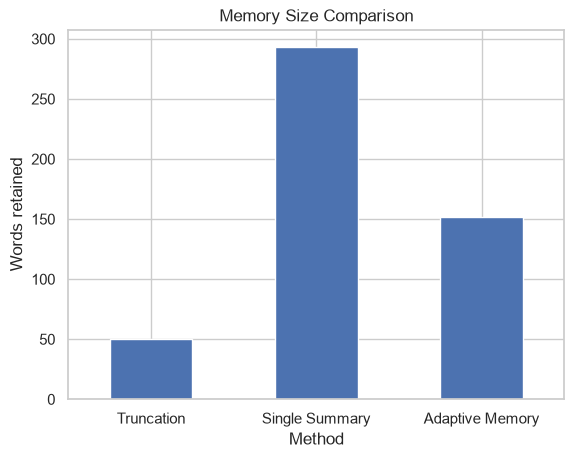

In [34]:
comparison.plot(
    x="method",
    y="text_units",
    kind="bar",
    legend=False
)

plt.ylabel("Words retained")
plt.xlabel("Method")
plt.title("Memory Size Comparison")
plt.xticks(rotation=0)
plt.show()

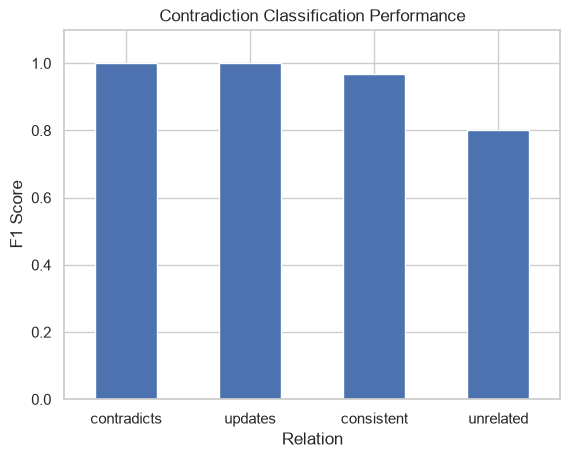

In [35]:
metrics_plot = metrics_df.set_index("label")["f1_score"]

metrics_plot.plot(
    kind="bar",
    legend=False
)

plt.ylabel("F1 Score")
plt.xlabel("Relation")
plt.title("Contradiction Classification Performance")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.show()

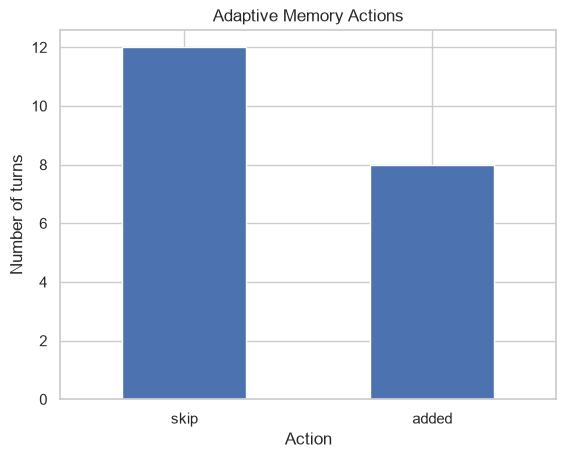

In [36]:
action_counts = df_adaptive_test["action"].value_counts()

action_counts.plot(
    kind="bar",
    legend=False
)

plt.ylabel("Number of turns")
plt.xlabel("Action")
plt.title("Adaptive Memory Actions")
plt.xticks(rotation=0)
plt.show()

In [37]:
qa = raw[0]["qa"]

print("Number of QA items:", len(qa))

print("\nFirst QA item:")
print(qa[0])

Number of QA items: 199

First QA item:
{'question': 'When did Caroline go to the LGBTQ support group?', 'answer': '7 May 2023', 'evidence': ['D1:3'], 'category': 2}


In [39]:
qa_item = qa[0]

conversation_id = raw[0]["sample_id"]
evidence_id = qa_item["evidence"][0]

evidence_turn = df_clean[
    (df_clean["conversation_id"] == conversation_id) &
    (df_clean["dia_id"] == evidence_id)
]

print("Conversation:", conversation_id)
print("Question:", qa_item["question"])
print("Answer:", qa_item["answer"])
print("Evidence ID:", evidence_id)

print("\nEvidence turn:")
display(evidence_turn[[
    "conversation_id",
    "session",
    "dia_id",
    "speaker",
    "text"
]])

Conversation: conv-26
Question: When did Caroline go to the LGBTQ support group?
Answer: 7 May 2023
Evidence ID: D1:3

Evidence turn:


,conversation_id,session,dia_id,speaker,text
2,conv-26,session_1,D1:3,Caroline,I went to a LGBTQ support group yesterday and ...


In [45]:
conv_id = "conv-26"

conv_qa = qa_df[
    qa_df["conversation_id"] == conv_id
].reset_index(drop=True)

print("Conversation:", conv_id)
print("Number of QA questions:", len(conv_qa))

display(
    conv_qa[
        ["question", "answer", "evidence", "category"]
    ].head(10)
)

Conversation: conv-26
Number of QA questions: 199


,question,answer,evidence,category
0,When did Caroline go to the LGBTQ support group?,7 May 2023,[D1:3],2
1,When did Melanie paint a sunrise?,2022,[D1:12],2
2,What fields would Caroline be likely to pursue...,"Psychology, counseling certification","[D1:9, D1:11]",3
3,What did Caroline research?,Adoption agencies,[D2:8],1
4,What is Caroline's identity?,Transgender woman,[D1:5],1
5,When did Melanie run a charity race?,The sunday before 25 May 2023,[D2:1],2
6,When is Melanie planning on going camping?,June 2023,[D2:7],2
7,What is Caroline's relationship status?,Single,"[D3:13, D2:14]",1
8,When did Caroline give a speech at a school?,The week before 9 June 2023,[D3:1],2
9,"When did Caroline meet up with her friends, fa...",The week before 9 June 2023,[D3:11],2


In [46]:
conv_data = df_clean[
    df_clean["conversation_id"] == "conv-26"
].reset_index(drop=True)

dia_positions = {
    dia_id: index
    for index, dia_id in enumerate(conv_data["dia_id"])
}

conv_qa["evidence_positions"] = conv_qa["evidence"].apply(
    lambda evidence_ids: [
        dia_positions[eid]
        for eid in evidence_ids
        if eid in dia_positions
    ]
)

conv_qa["latest_evidence_position"] = conv_qa[
    "evidence_positions"
].apply(
    lambda positions: max(positions) if positions else None
)

print("Conversation turns:", len(conv_data))
print("QA questions:", len(conv_qa))

display(
    conv_qa[
        [
            "question",
            "answer",
            "evidence",
            "evidence_positions",
            "latest_evidence_position"
        ]
    ].head(10)
)

Conversation turns: 419
QA questions: 199


,question,answer,evidence,evidence_positions,latest_evidence_position
0,When did Caroline go to the LGBTQ support group?,7 May 2023,[D1:3],[2],2.0
1,When did Melanie paint a sunrise?,2022,[D1:12],[11],11.0
2,What fields would Caroline be likely to pursue...,"Psychology, counseling certification","[D1:9, D1:11]","[8, 10]",10.0
3,What did Caroline research?,Adoption agencies,[D2:8],[25],25.0
4,What is Caroline's identity?,Transgender woman,[D1:5],[4],4.0
5,When did Melanie run a charity race?,The sunday before 25 May 2023,[D2:1],[18],18.0
6,When is Melanie planning on going camping?,June 2023,[D2:7],[24],24.0
7,What is Caroline's relationship status?,Single,"[D3:13, D2:14]","[47, 31]",47.0
8,When did Caroline give a speech at a school?,The week before 9 June 2023,[D3:1],[35],35.0
9,"When did Caroline meet up with her friends, fa...",The week before 9 June 2023,[D3:11],[45],45.0


In [47]:
checkpoints = [50, 100, 200, 300, 400]

coverage_results = []

for checkpoint in checkpoints:
    available_questions = (
        conv_qa["latest_evidence_position"] < checkpoint
    ).sum()

    coverage = available_questions / len(conv_qa)

    coverage_results.append({
        "conversation_length": checkpoint,
        "questions_with_evidence": available_questions,
        "total_questions": len(conv_qa),
        "evidence_coverage": coverage
    })

coverage_df = pd.DataFrame(coverage_results)

display(coverage_df)

,conversation_length,questions_with_evidence,total_questions,evidence_coverage
0,50,24,199,0.120603
1,100,57,199,0.286432
2,200,97,199,0.487437
3,300,135,199,0.678392
4,400,191,199,0.959799


In [48]:
def get_truncation_evidence_coverage(conv_data, conv_qa, checkpoint, keep_last=3):
    retained_dia_ids = set(
        conv_data.iloc[:checkpoint].tail(keep_last)["dia_id"]
    )

    covered = 0

    for evidence_ids in conv_qa["evidence"]:
        if all(evidence_id in retained_dia_ids for evidence_id in evidence_ids):
            covered += 1

    return covered


truncation_results = []

for checkpoint in checkpoints:
    covered = get_truncation_evidence_coverage(
        conv_data,
        conv_qa,
        checkpoint,
        keep_last=3
    )

    truncation_results.append({
        "conversation_length": checkpoint,
        "questions_covered": covered,
        "total_questions": len(conv_qa),
        "coverage": covered / len(conv_qa)
    })

truncation_coverage_df = pd.DataFrame(truncation_results)

display(truncation_coverage_df)

,conversation_length,questions_covered,total_questions,coverage
0,50,3,199,0.015075
1,100,2,199,0.010050
2,200,2,199,0.010050
3,300,2,199,0.010050
4,400,2,199,0.010050


In [49]:
adaptive_memories = get_store().get_all("conv-26_adaptive_test")

adaptive_memory_texts = {
    memory["text"]
    for memory in adaptive_memories
}

first_20_turns = conv_data.iloc[:20]

covered = 0

for evidence_ids in conv_qa["evidence"]:
    evidence_texts = set(
        first_20_turns[
            first_20_turns["dia_id"].isin(evidence_ids)
        ]["text"]
    )

    if evidence_texts and evidence_texts.issubset(adaptive_memory_texts):
        covered += 1

print("Adaptive Memory pilot")
print("Turns processed:", 20)
print("Memories stored:", len(adaptive_memories))
print("Questions whose evidence was retained:", covered)
print("Total questions:", len(conv_qa))
print("Evidence coverage:", f"{covered / len(conv_qa):.2%}")

Adaptive Memory pilot
Turns processed: 20
Memories stored: 8
Questions whose evidence was retained: 6
Total questions: 199
Evidence coverage: 3.02%


## Findings

- The LoCoMo dataset contains 5,882 conversation turns across 10 conversations.
- The cleaning process removed no rows because the dataset contained no missing text or duplicate dialogue IDs in the selected fields.
- In the 20-turn adaptive memory pilot, 8 turns were stored and 12 were skipped.
- The adaptive memory pilot retained 152 words, compared with 50 words for truncation and 293 words for the single-summary baseline.
- On the 20 manually labelled contradiction test cases, the classifier achieved 95% overall accuracy.
- The F1 score was highest for contradictions and updates, while unrelated statements were the most difficult category.

## Limitations

- The contradiction evaluation contains only 20 manually labelled cases and is therefore a pilot evaluation.
- The contradicts and updates categories contain only one example each, so their individual F1 scores should not be treated as conclusive.
- The memory-size comparison is a pilot comparison because the adaptive-memory result was generated from a 20-turn sample, while the truncation and summary baselines used the full 419-turn conversation.
- The current results should not be treated as the final benchmark comparison of the three methods.